# Week 3: Exploring the Synthetic Event Dataset

Before building any machine learning models, you need to know your data inside out. This notebook
explores the raw synthetic event dataset generated by `generate_events.py` — 50,000 events across
200 simulated trading platform users, with 10 distinct fraud patterns deliberately injected.

The goal here isn't to build anything. It's to get a feel for what normal looks like, what
suspicious looks like, and where the meaningful signals are hiding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/raw/events.csv", parse_dates=["timestamp"])
print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"\nNull counts per column (showing only non-zero):")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].to_string())

Shape: (50000, 31)
Date range: 2024-01-01 to 2024-03-30
Unique users: 200

Null counts per column (showing only non-zero):
ip_address                  38907
country                     38909
device                      32934
login_success               38907
failed_attempts             38907
timezone_gap_hours          38932
instrument                  32503
lot_size                    32503
trade_volume                32503
pnl                         32503
margin_used                 32503
trade_duration_seconds      32503
trade_volume_vs_baseline    32503
is_night_trade              32503
amount                      37380
method                      37380
is_immediate_withdrawal     37405
session_duration_mins       44011
page_clicks                 44011
click_rate_per_min          44011
kyc_change_type             47070


## Dataset Overview

The dataset has **50,000 rows and 31 columns**, covering January 1 to March 30, 2024. Most of the
null values are expected — event-specific columns like `trade_volume` only get populated for
trade events, `click_rate_per_min` only for session events, etc. These nulls aren't a data quality
problem; they're structural.

Two columns tell us whether a row is fraud: `is_anomalous` (0/1 flag) and `anomaly_type` (the
specific fraud category, or `"none"` for normal events). These exist because we injected the
anomalies ourselves — in a real system, you'd never have these labels for every event.

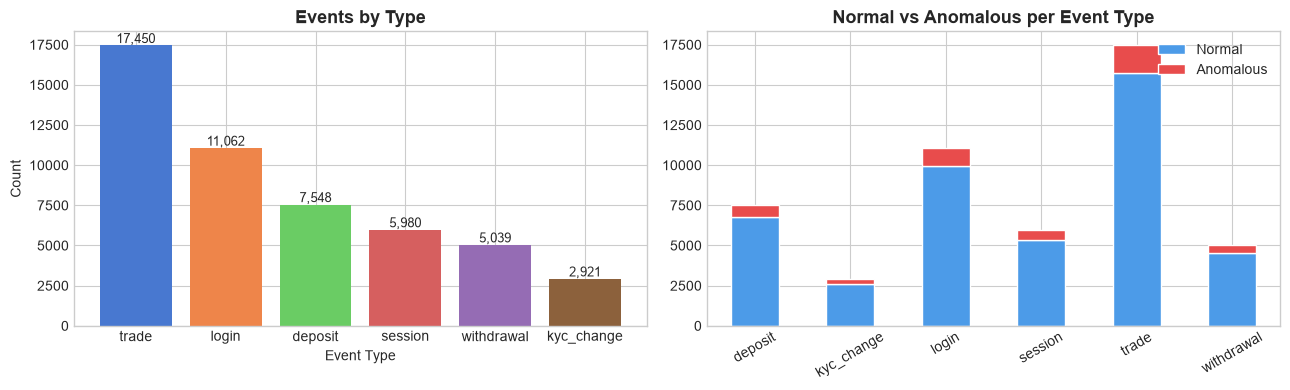

event_type
trade         17450
login         11062
deposit        7548
session        5980
withdrawal     5039
kyc_change     2921
Name: count, dtype: int64


In [2]:
# ── 1. Event type distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df["event_type"].value_counts()
colors = sns.color_palette("muted", len(vc))
bars = axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_title("Events by Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 150,
                 f"{v:,}", ha="center", fontsize=9)

cross = df.groupby(["event_type", "is_anomalous"]).size().unstack(fill_value=0)
cross.columns = ["Normal", "Anomalous"]
cross.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c9be8", "#e84c4c"], edgecolor="white")
axes[1].set_title("Normal vs Anomalous per Event Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].legend(loc="upper right")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../reports/figures/event_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["event_type"].value_counts())

**Observation:** Trades dominate at ~35% — makes sense for a trading platform. KYC changes are
the rarest at ~6%, which also tracks (people don't update their identity documents often).
The anomalous events appear in every category, though some (like `deposit` and `withdrawal`) have
a noticeably higher anomalous fraction due to fraud patterns like the deposit-withdrawal cycler
and the structurer.

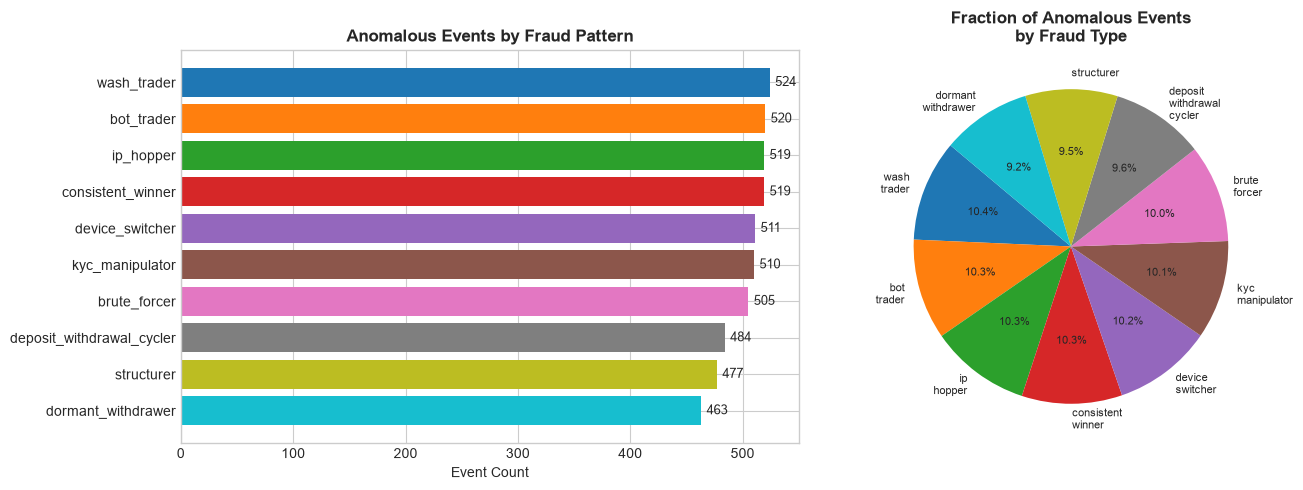

Total anomalous events: 5,032 / 50,000 (10.1%)
Total anomalous users: 20 / 200


In [3]:
# ── 2. Anomaly type breakdown ─────────────────────────────────────────────────
anom_df = df[df["is_anomalous"] == 1]
vc_anom = anom_df["anomaly_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_anom = sns.color_palette("tab10", len(vc_anom))
bars = axes[0].barh(vc_anom.index, vc_anom.values, color=colors_anom)
axes[0].set_title("Anomalous Events by Fraud Pattern", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Event Count")
axes[0].invert_yaxis()
for bar, val in zip(bars, vc_anom.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9)

# Pie chart of anomaly distribution
axes[1].pie(vc_anom.values, labels=[l.replace("_", "\n") for l in vc_anom.index],
            colors=colors_anom, autopct="%1.1f%%", startangle=140,
            textprops={"fontsize": 8})
axes[1].set_title("Fraction of Anomalous Events\nby Fraud Type", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_type_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total anomalous events: {len(anom_df):,} / {len(df):,} ({len(anom_df)/len(df)*100:.1f}%)")
print(f"Total anomalous users: {anom_df['user_id'].nunique()} / {df['user_id'].nunique()}")

**Observation:** 5,032 out of 50,000 events are flagged as anomalous — roughly 10%. The
distribution across fraud types is fairly even, which is by design: the generator cycles through
all 10 types and assigns 2 users per type. Wash traders generate the most events (524) because
the generator creates 10 trades per user × 2 users, plus all their background activity is also
labeled anomalous. Dormant withdrawers have the fewest injected burst events (3 withdrawals per
user).

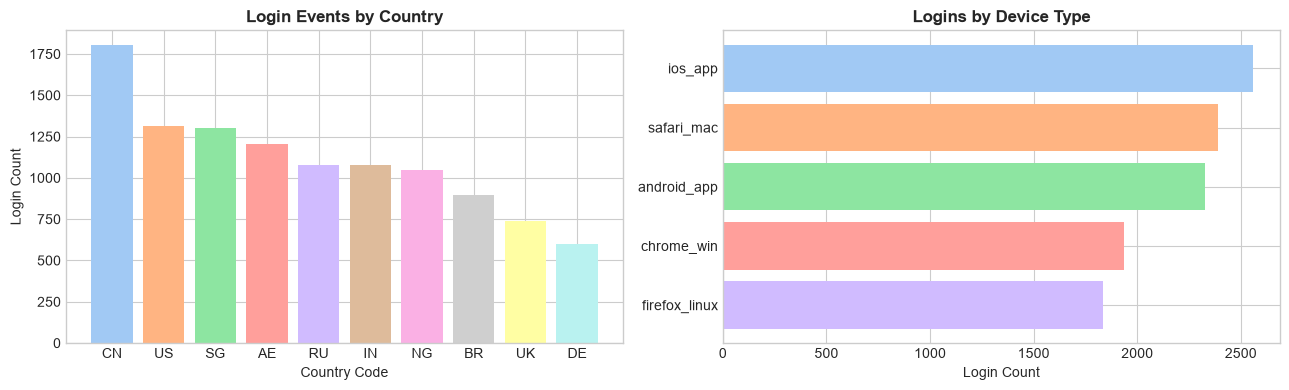

Country breakdown:
country
CN    1802
US    1312
SG    1304
AE    1206
RU    1077
IN    1075
NG    1048
BR     899
UK     737
DE     600

Device breakdown:
device
ios_app          2561
safari_mac       2388
android_app      2329
chrome_win       1938
firefox_linux    1836


In [4]:
# ── 3. Geographic and device distribution ─────────────────────────────────────
login_df = df[df["event_type"] == "login"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

country_vc = login_df["country"].value_counts()
axes[0].bar(country_vc.index, country_vc.values, color=sns.color_palette("pastel", len(country_vc)))
axes[0].set_title("Login Events by Country", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Login Count")
axes[0].set_xlabel("Country Code")

device_vc = login_df["device"].value_counts()
axes[1].barh(device_vc.index, device_vc.values, color=sns.color_palette("pastel", len(device_vc)))
axes[1].set_title("Logins by Device Type", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Login Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../reports/figures/geo_device_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Country breakdown:"); print(country_vc.to_string())
print("\nDevice breakdown:"); print(device_vc.to_string())

**Observation:** Countries are fairly uniformly distributed since users are randomly assigned home
countries. The device mix looks realistic — Chrome on Windows and Safari on Mac lead, with mobile
apps trailing. If you saw a real platform heavily skewed toward one country or device, that would
itself be a signal worth investigating.

/var/folders/xr/48xq2ryx7llf7nczkz327zvm0000gn/T/ipykernel_53479/2644058882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trade_df, x="user_type", y="trade_volume", ax=axes[0],


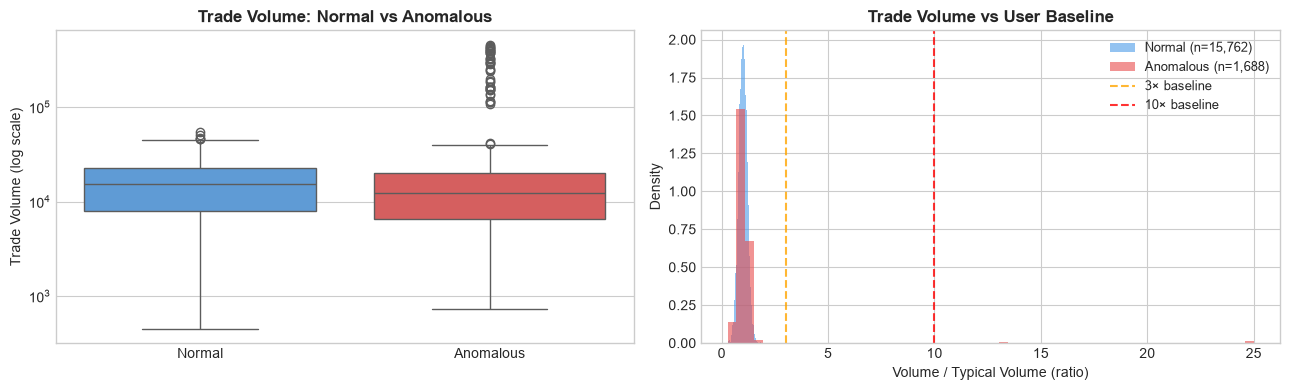

Wash trader vol_vs_baseline range: 0.5x to 20.0x
Wash trader positive PnL: 113/201


In [5]:
# ── 4. Normal vs anomalous trade volume ───────────────────────────────────────
trade_df = df[df["event_type"] == "trade"].copy()
trade_df["user_type"] = trade_df["is_anomalous"].map({0: "Normal", 1: "Anomalous"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=trade_df, x="user_type", y="trade_volume", ax=axes[0],
            palette={"Normal": "#4c9be8", "Anomalous": "#e84c4c"})
axes[0].set_yscale("log")
axes[0].set_title("Trade Volume: Normal vs Anomalous", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Trade Volume (log scale)")
axes[0].set_xlabel("")

# The key signal: trade_volume_vs_baseline
trade_df_notna = trade_df.dropna(subset=["trade_volume_vs_baseline"])
for label, color in [("Normal", "#4c9be8"), ("Anomalous", "#e84c4c")]:
    sub = trade_df_notna[trade_df_notna["user_type"]==label]["trade_volume_vs_baseline"]
    sub_clipped = sub.clip(upper=25)
    axes[1].hist(sub_clipped, bins=60, alpha=0.6, color=color,
                 label=f"{label} (n={len(sub):,})", density=True)
axes[1].set_title("Trade Volume vs User Baseline", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Volume / Typical Volume (ratio)")
axes[1].set_ylabel("Density")
axes[1].axvline(x=3, color="orange", linestyle="--", alpha=0.8, label="3× baseline")
axes[1].axvline(x=10, color="red", linestyle="--", alpha=0.8, label="10× baseline")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/trade_volume_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

wash_trades = df[(df["anomaly_type"]=="wash_trader") & (df["event_type"]=="trade")]
print(f"Wash trader vol_vs_baseline range: {wash_trades['trade_volume_vs_baseline'].min():.1f}x to {wash_trades['trade_volume_vs_baseline'].max():.1f}x")
print(f"Wash trader positive PnL: {(wash_trades['pnl']>0).sum()}/{len(wash_trades)}")

**Observation:** The log-scale boxplot shows wash traders (anomalous) generating trades at
significantly higher absolute volumes. The ratio plot is more revealing: normal users trade very
close to their typical volume (around 1.0×), while wash traders hit 10-20× their baseline. A
10× volume spike compared to a user's own history is a strong red flag. Interestingly, wash
traders don't always profit — 113 out of 201 wash trade events show positive PnL. That's ~56%,
only slightly above chance. The signal here is volume, not win rate.

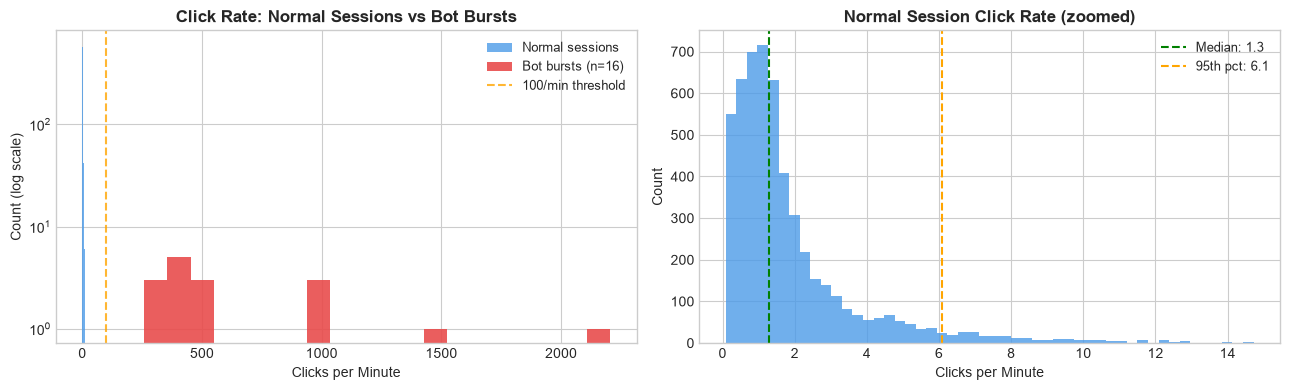

Normal click rate: median=1.3, 95th pct=6.1, 99th=10.2/min
Bot burst sessions: 16, range: 258-2205/min


In [6]:
# ── 5. Click rate analysis — bot detection ────────────────────────────────────
sess_df = df[df["event_type"] == "session"].dropna(subset=["click_rate_per_min"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All sessions on log scale
normal_cr = sess_df[sess_df["is_anomalous"]==0]["click_rate_per_min"]
axes[0].hist(normal_cr, bins=60, color="#4c9be8", alpha=0.8, label="Normal sessions")
bot_burst = df[(df["anomaly_type"]=="bot_trader") & (df["event_type"]=="session") &
               (df["click_rate_per_min"] > 100)]["click_rate_per_min"]
axes[0].hist(bot_burst, bins=20, color="#e84c4c", alpha=0.9, label=f"Bot bursts (n={len(bot_burst)})")
axes[0].set_yscale("log")
axes[0].set_title("Click Rate: Normal Sessions vs Bot Bursts", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Clicks per Minute")
axes[0].set_ylabel("Count (log scale)")
axes[0].axvline(x=100, color="orange", linestyle="--", alpha=0.8, label="100/min threshold")
axes[0].legend(fontsize=9)

# Right: zoom into the normal range
axes[1].hist(normal_cr[normal_cr <= 20], bins=50, color="#4c9be8", alpha=0.8)
axes[1].set_title("Normal Session Click Rate (zoomed)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Clicks per Minute")
axes[1].set_ylabel("Count")
p50 = normal_cr.quantile(0.50)
p95 = normal_cr.quantile(0.95)
axes[1].axvline(p50, color="green", linestyle="--", label=f"Median: {p50:.1f}")
axes[1].axvline(p95, color="orange", linestyle="--", label=f"95th pct: {p95:.1f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/click_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Normal click rate: median={normal_cr.median():.1f}, 95th pct={normal_cr.quantile(0.95):.1f}, 99th={normal_cr.quantile(0.99):.1f}/min")
print(f"Bot burst sessions: {len(bot_burst)}, range: {bot_burst.min():.0f}-{bot_burst.max():.0f}/min")

**Observation:** This is one of the cleanest signals in the dataset. Normal sessions max out at
around 10-15 clicks/minute at the 99th percentile. The bot burst sessions jump to 258-2205
clicks/minute — that's 20-170× the normal range. Only 16 sessions in total hit above 100/min,
and they're all from the bot_trader users.

The challenge is that bot_trader users also generate many normal sessions. If you set a threshold
at 100/min, you'd catch only the 16 burst sessions and miss all the normal activity from the same
user. A user-level model that tracks their session history would be far more effective.

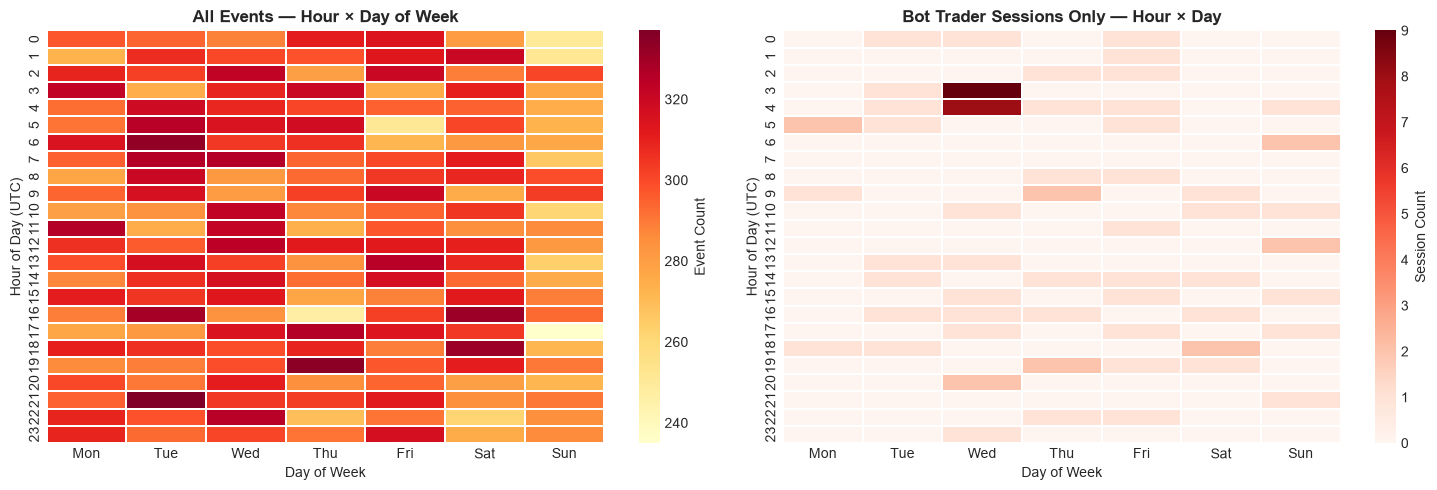

In [7]:
# ── 6. Temporal activity heatmap ──────────────────────────────────────────────
pivot = df.groupby(["hour_of_day", "day_of_week"]).size().unstack(fill_value=0)
day_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
pivot.columns = [day_names[d] for d in pivot.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(pivot, cmap="YlOrRd", ax=axes[0], linewidths=0.3,
            cbar_kws={"label": "Event Count"})
axes[0].set_title("All Events — Hour × Day of Week", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Hour of Day (UTC)")

# Bot trader sessions specifically
bot_sess = df[(df["anomaly_type"]=="bot_trader") & (df["event_type"]=="session")]
bot_pivot = bot_sess.groupby(["hour_of_day", "day_of_week"]).size().unstack(fill_value=0)
bot_pivot.columns = [day_names.get(d, d) for d in bot_pivot.columns]
# reindex to show full 0-23 range
bot_pivot = bot_pivot.reindex(range(24), fill_value=0)
sns.heatmap(bot_pivot, cmap="Reds", ax=axes[1], linewidths=0.3,
            cbar_kws={"label": "Session Count"})
axes[1].set_title("Bot Trader Sessions Only — Hour × Day", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Hour of Day (UTC)")

plt.tight_layout()
plt.savefig("../reports/figures/temporal_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** The overall event distribution is fairly uniform across the week — expected since
the data was generated with random timestamps. The bot trader heatmap is more interesting: the
sessions cluster tightly in the 2-4 AM UTC window (hours 2, 3, 4), with activity hitting on
specific days. Real platforms see bots operating during off-peak hours precisely because lower
human activity means less competition and more predictable market conditions.

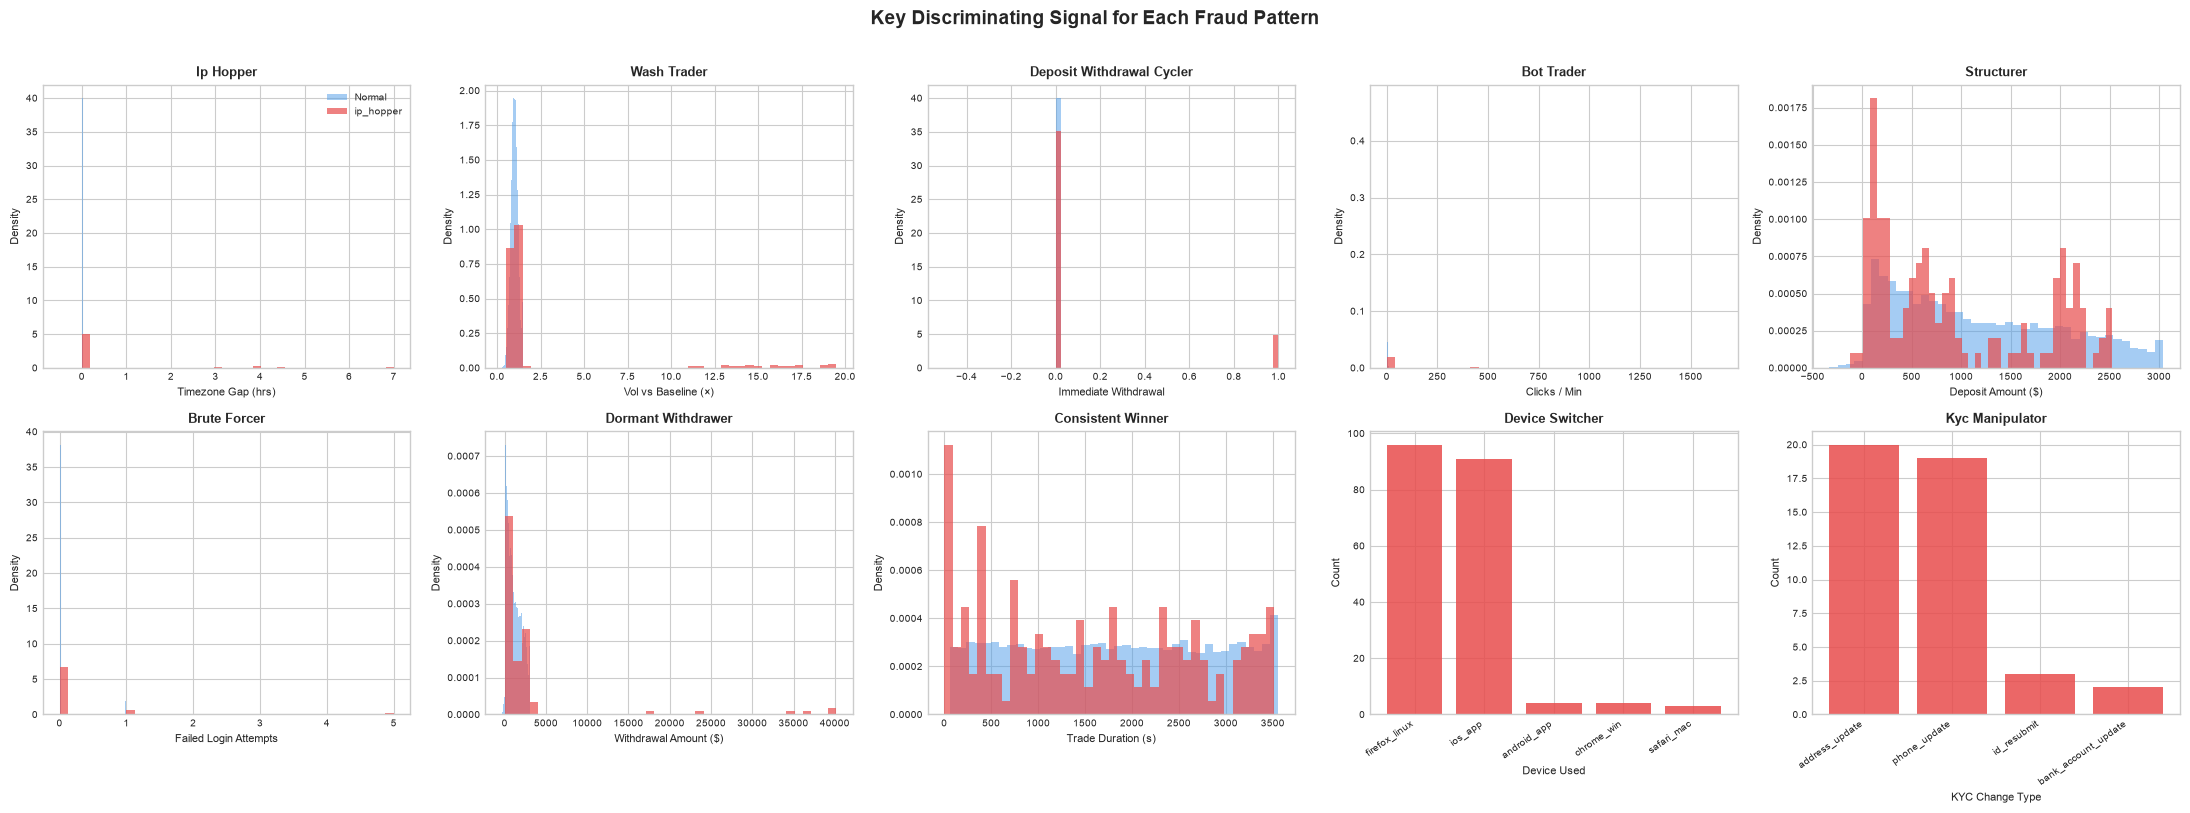

In [8]:
# ── 7. Fraud signal overview — one subplot per anomaly type ──────────────────
anomaly_signals = [
    ("ip_hopper",                 "timezone_gap_hours",       "Timezone Gap (hrs)"),
    ("wash_trader",               "trade_volume_vs_baseline",  "Vol vs Baseline (×)"),
    ("deposit_withdrawal_cycler", "is_immediate_withdrawal",   "Immediate Withdrawal"),
    ("bot_trader",                "click_rate_per_min",        "Clicks / Min"),
    ("structurer",                "amount",                    "Deposit Amount ($)"),
    ("brute_forcer",              "failed_attempts",           "Failed Login Attempts"),
    ("dormant_withdrawer",        "amount",                    "Withdrawal Amount ($)"),
    ("consistent_winner",         "trade_duration_seconds",    "Trade Duration (s)"),
    ("device_switcher",           "device",                    "Device Used"),
    ("kyc_manipulator",           "kyc_change_type",           "KYC Change Type"),
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
normal_df = df[df["is_anomalous"] == 0]

for idx, (atype, col, label) in enumerate(anomaly_signals):
    ax = axes[idx]
    anom_sub  = df[df["anomaly_type"] == atype].dropna(subset=[col])
    norm_sub  = normal_df.dropna(subset=[col])
    title = atype.replace("_", " ").title()

    is_categorical = not pd.api.types.is_numeric_dtype(df[col])
    if is_categorical:
        vc = anom_sub[col].value_counts().head(5)
        ax.bar(range(len(vc)), vc.values, color="#e84c4c", alpha=0.85)
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels(vc.index, rotation=35, ha="right", fontsize=7)
    else:
        clip_n = norm_sub[col].quantile(0.99)
        clip_a = anom_sub[col].quantile(0.99)
        ax.hist(norm_sub[col].clip(upper=clip_n), bins=40, alpha=0.5,
                color="#4c9be8", label="Normal", density=True)
        ax.hist(anom_sub[col].clip(upper=clip_a), bins=40, alpha=0.7,
                color="#e84c4c", label=atype, density=True)
        if idx == 0: ax.legend(fontsize=7)

    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel("Count" if is_categorical else "Density", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Key Discriminating Signal for Each Fraud Pattern",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/anomaly_signals_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Observations

Looking across all 10 fraud patterns, a few signals stand out as particularly clean:

**Strongest signals:**
- **Bot trader**: click_rate_per_min of 258-2205/min vs normal max of ~15/min. On a log scale
  this is immediately visible. The 16 burst sessions are unmistakable.
- **Consistent winner**: trade_duration_seconds of 1-10s vs normal range of 60-3600s. No overlap.
- **Brute forcer**: failed_attempts reaches 5 before a successful login. Normal users never
  exceed 1 failed attempt.
- **Dormant withdrawer**: withdrawal amounts of $15,000-$43,217 vs normal withdrawals which are
  much lower.

**Subtler signals (harder to detect without context):**
- **Structurer**: deposits are in the $490-$999 range, but so are some normal deposits. The
  pattern only becomes clear when you look at the *sequence* — many deposits just below $1,000
  in quick succession. A single structurer deposit looks normal in isolation.
- **IP hopper**: timezone_gap_hours is 0-8. The signal is in the *rate* of country switching,
  not a single value. 8 different countries in 2 hours is the tell.
- **Device switcher**: each individual login uses a plausible device. The anomaly is that no
  two consecutive logins use the same device.

**Challenge for modeling (Week 5-6):** Most events from anomalous users look perfectly normal.
The fraud signal is concentrated in a small burst of events per user, surrounded by hundreds of
legitimate-looking events. An unsupervised model that sees these users as a whole might not flag
them at all — it needs to detect the anomalous EPISODES within the user's history.